In [1]:
import numpy as np
import tensorflow as tf
import cv2

from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

from tensorflow.keras.applications.resnet50 import ResNet50, decode_predictions, preprocess_input
#from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
#from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2B3, preprocess_input, decode_predictions
#from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input, decode_predictions


2026-08-19 19:55:39.080863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787190939.109697 1289470 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787190939.119451 1289470 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787190939.141920 1289470 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787190939.141964 1289470 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787190939.141965 1289470 computation_placer.cc:177] computation placer alr

In [2]:
model_resnet = ResNet50(weights='imagenet')
#model_mobile = MobileNetV2(weights='imagenet')
#model_eff = EfficientNetV2B3(weights='imagenet')
#model_incep = InceptionV3(weights='imagenet')

I0000 00:00:1787190948.834759 1289470 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


In [3]:
model = model_resnet

In [4]:
alto = model.input_shape[1]
ancho = model.input_shape[2]

In [5]:
print(alto, ancho)

224 224


In [6]:
# img_path = tf.keras.utils.get_file(
#     'horse.jpg',
#     'https://concepto.de/wp-content/uploads/2021/07/caballos-e1626738224231.jpg'
# )

img_path = '/home/gibran/Downloads/beautiful-brown-horse-stands-gracefully-260nw-2656937037.webp'

img = image.load_img(img_path, target_size=(alto, ancho))

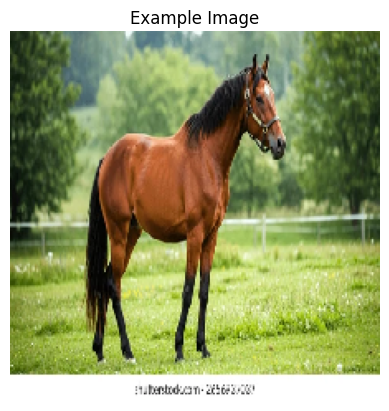

In [7]:
plt.imshow(img)
plt.title("Example Image")
plt.axis("off")
plt.show()

In [8]:
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)      # Formato: (batch_size, alto, ancho, canales)
x = preprocess_input(x)            # Normalización específica del modelo

In [9]:
# 3. Realizar predicción
preds = model.predict(x)

I0000 00:00:1787190971.553183 1289657 service.cc:152] XLA service 0x715018002f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787190971.553231 1289657 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Ti SUPER, Compute Capability 8.9
2026-08-19 19:56:11.695266: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787190973.028598 1289657 cuda_dnn.cc:529] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


I0000 00:00:1787190975.272283 1289657 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [10]:
print("--- Predicciones Top 3 ---")
for pred in decode_predictions(preds, top=3)[0]:
    print(f"{pred[1]}: {pred[2] * 100:.2f}%")

--- Predicciones Top 3 ---
sorrel: 99.71%
worm_fence: 0.12%
hartebeest: 0.10%
